# Stochastic Modeling of Flight Delay Propagation

The follow jupyter notebook contains data analysis of how flight delays propagate through individual aircrafts daily routes. The goal of this notebook is to impliment a markov chain and calculate its transition matrix to understand how flights switch through states. This project uses the [BTS Marketing Carrier On-Time Peformance](https://www.transtats.bts.gov/tables.asp?QO_VQ=EFD&QO_anzr=Nv4yv0r) database for analysis. The dataset contains the following columns:
* DAY_OF_WEEK(int) - A number associted to the day of the week the flight took place
* FL_DATE(String) - The date of the flight in d/m/yyyy 12:00:00 AM format
* OP_CARRIER_AIRLINE_ID(int) - A DOT assigned code for the operating airline
* TAIL_NUM(String) - The tail number of the aircraft
* OP_CARRIER_FL_NUM(int) - The flight number used by the operating airline
* ORIGIN(String) - The IATA airport code for the airport of origin
* ORIGIN_CITY_NAME(String) - The city of origin
* DEST(String) - The IATA airport code for the destination airport
* DEST_CITY_NAME(String) - The city of destination
* CRS_DEP_TIME(int) - The planned time of departure (local time hhmm)
* DEP_TIME(float64) - The actual time of departure (local time hhmm)
* DEP_DELAY(float64) - The departure delay in minutes. negative minutes indicating an early departure
* CRS_ARR_TIME(int) - The planned time of arrival (local time hhmm)
* ARR_TIME(float64) - The actual time of arrival (local time hhmm)
* ARR_DELAY(float64) - The arrival delay in minutes. negative minutes indicating an early arrival
* CANCELLED(float64) - 1 if the flight was cancelled
* DUP(String) - Indicates a swapped flight record
* CRS_ELAPSED_TIME(float64) - The planned flight time in minutes
* ACTUAL_ELAPSED_TIME(float64) - The actual flight time in minutes

## Data Preprocessing

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import airportsdata

In [2]:
#import data
delay_df = pd.read_csv('datasets/flight_delays.csv')
delay_df.head()

,DAY_OF_WEEK,FL_DATE,OP_CARRIER_AIRLINE_ID,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN,ORIGIN_CITY_NAME,DEST,DEST_CITY_NAME,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,DUP,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME
0,1,7/7/2025 12:00:00 AM,20363,N131EV,5189,BUF,"Buffalo, NY",DTW,"Detroit, MI",1552,1555.0,3.0,1702,1703.0,1.0,0.0,N,70.0,68.0
1,1,7/7/2025 12:00:00 AM,20363,N131EV,5296,JFK,"New York, NY",BUF,"Buffalo, NY",1329,1321.0,-8.0,1512,1512.0,0.0,0.0,N,103.0,111.0
2,1,7/7/2025 12:00:00 AM,20363,N131EV,5329,DTW,"Detroit, MI",CVG,"Cincinnati, OH",1820,1814.0,-6.0,1933,1914.0,-19.0,0.0,N,73.0,60.0
3,1,7/7/2025 12:00:00 AM,20363,N131EV,5330,JFK,"New York, NY",ROC,"Rochester, NY",900,925.0,25.0,1035,1047.0,12.0,0.0,N,95.0,82.0
4,1,7/7/2025 12:00:00 AM,20363,N131EV,5330,ROC,"Rochester, NY",JFK,"New York, NY",1115,1130.0,15.0,1239,1242.0,3.0,0.0,N,84.0,72.0


In [3]:
delay_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 696049 entries, 0 to 696048
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   DAY_OF_WEEK            696049 non-null  int64  
 1   FL_DATE                696049 non-null  object 
 2   OP_CARRIER_AIRLINE_ID  696049 non-null  int64  
 3   TAIL_NUM               693619 non-null  object 
 4   OP_CARRIER_FL_NUM      696049 non-null  int64  
 5   ORIGIN                 696049 non-null  object 
 6   ORIGIN_CITY_NAME       696049 non-null  object 
 7   DEST                   696049 non-null  object 
 8   DEST_CITY_NAME         696049 non-null  object 
 9   CRS_DEP_TIME           696049 non-null  int64  
 10  DEP_TIME               679234 non-null  float64
 11  DEP_DELAY              679172 non-null  float64
 12  CRS_ARR_TIME           696049 non-null  int64  
 13  ARR_TIME               677870 non-null  float64
 14  ARR_DELAY              674741 non-nu

In [4]:
delay_df.isnull().sum()

DAY_OF_WEEK                  0
FL_DATE                      0
OP_CARRIER_AIRLINE_ID        0
TAIL_NUM                  2430
OP_CARRIER_FL_NUM            0
ORIGIN                       0
ORIGIN_CITY_NAME             0
DEST                         0
DEST_CITY_NAME               0
CRS_DEP_TIME                 0
DEP_TIME                 16815
DEP_DELAY                16877
CRS_ARR_TIME                 0
ARR_TIME                 18179
ARR_DELAY                21308
CANCELLED                    0
DUP                          0
CRS_ELAPSED_TIME             0
ACTUAL_ELAPSED_TIME      21308
dtype: int64

In [5]:
# view flights with null tail numbers
delay_df[ delay_df['TAIL_NUM'].isnull() ].sample(5)

,DAY_OF_WEEK,FL_DATE,OP_CARRIER_AIRLINE_ID,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN,ORIGIN_CITY_NAME,DEST,DEST_CITY_NAME,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,DUP,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME
634430,7,7/13/2025 12:00:00 AM,20436,NaN,2924,ONT,"Ontario, CA",DFW,"Dallas/Fort Worth, TX",2009,NaN,NaN,124,NaN,NaN,1.0,N,195.0,NaN
267215,3,7/16/2025 12:00:00 AM,20378,NaN,6073,IAD,"Washington, DC",BDL,"Hartford, CT",1715,NaN,NaN,1851,NaN,NaN,1.0,N,96.0,NaN
677775,7,7/27/2025 12:00:00 AM,20445,NaN,4339,IAD,"Washington, DC",ROA,"Roanoke, VA",1730,NaN,NaN,1846,NaN,NaN,1.0,N,76.0,NaN
414898,4,7/31/2025 12:00:00 AM,20436,NaN,1445,CLT,"Charlotte, NC",MCO,"Orlando, FL",1903,NaN,NaN,2058,NaN,NaN,1.0,N,115.0,NaN
630977,7,7/13/2025 12:00:00 AM,20445,NaN,4379,IAH,"Houston, TX",BTR,"Baton Rouge, LA",1409,NaN,NaN,1527,NaN,NaN,1.0,N,78.0,NaN


In [6]:
#count of cancelled flights
delay_df.CANCELLED.value_counts()

CANCELLED
0.0    678101
1.0     17948
Name: count, dtype: int64

In [7]:
#count of duplicate flights
delay_df.DUP.value_counts()

DUP
N    696049
Name: count, dtype: int64

In [8]:
delay_df[delay_df.CANCELLED == 0].isnull().sum()

DAY_OF_WEEK                 0
FL_DATE                     0
OP_CARRIER_AIRLINE_ID       0
TAIL_NUM                    0
OP_CARRIER_FL_NUM           0
ORIGIN                      0
ORIGIN_CITY_NAME            0
DEST                        0
DEST_CITY_NAME              0
CRS_DEP_TIME                0
DEP_TIME                    0
DEP_DELAY                   0
CRS_ARR_TIME                0
ARR_TIME                  231
ARR_DELAY                3360
CANCELLED                   0
DUP                         0
CRS_ELAPSED_TIME            0
ACTUAL_ELAPSED_TIME      3360
dtype: int64

We can see that most null values are attributed to the flight being cancelled with the exception of arrival time and arrival delay. According to the BTS metadata, flights that were diverted end up having null arrival times. Therefore, we can attribute these null values to diverted flights. Since these values account for a small fraction of the dataset, it is safe to ignore these while constructing our markov chain.

### Time handling
We must handle times columns prior to creating the Markov chain. These columns are currently strings and ints rather than proper datetime objects and need cleaning. FL_DATE is a string, and arrival and depature times are numeric rather than timestamps. These values are all in local time as well. We will need to be able to compare flights across timezones.The current FL_DATE only accounts for the scheduled departure time, but not cases where flights are delayed to the next day.

In [9]:
#convert FL_DATE to datetime
delay_df['FL_DATE'] = pd.to_datetime(delay_df['FL_DATE'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')

In [14]:
#Format local CRS departure time 

#pad to 4 digits
delay_df['CRS_DEP_LT'] = pd.to_numeric(delay_df['CRS_DEP_TIME'], errors='coerce').fillna(0).astype(int).astype(str).str.zfill(4)

#replace flights at midnight with 2359 for dt handling
delay_df['CRS_DEP_LT'] = delay_df['CRS_DEP_LT'].replace('2400', '2359')

#convert to datetime
delay_df['CRS_DEP_LT'] = pd.to_datetime(delay_df['FL_DATE'].dt.strftime('%Y-%m-%d') + ' ' + delay_df['CRS_DEP_LT'].str[:2] + ':' + delay_df['CRS_DEP_LT'].str[2:], format='%Y-%m-%d %H:%M', errors='coerce')
delay_df.head()

,DAY_OF_WEEK,FL_DATE,OP_CARRIER_AIRLINE_ID,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN,ORIGIN_CITY_NAME,DEST,DEST_CITY_NAME,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,DUP,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,CRS_DEP_LT
0,1,2025-07-07,20363,N131EV,5189,BUF,"Buffalo, NY",DTW,"Detroit, MI",1552,1555.0,3.0,1702,1703.0,1.0,0.0,N,70.0,68.0,2025-07-07 15:52:00
1,1,2025-07-07,20363,N131EV,5296,JFK,"New York, NY",BUF,"Buffalo, NY",1329,1321.0,-8.0,1512,1512.0,0.0,0.0,N,103.0,111.0,2025-07-07 13:29:00
2,1,2025-07-07,20363,N131EV,5329,DTW,"Detroit, MI",CVG,"Cincinnati, OH",1820,1814.0,-6.0,1933,1914.0,-19.0,0.0,N,73.0,60.0,2025-07-07 18:20:00
3,1,2025-07-07,20363,N131EV,5330,JFK,"New York, NY",ROC,"Rochester, NY",900,925.0,25.0,1035,1047.0,12.0,0.0,N,95.0,82.0,2025-07-07 09:00:00
4,1,2025-07-07,20363,N131EV,5330,ROC,"Rochester, NY",JFK,"New York, NY",1115,1130.0,15.0,1239,1242.0,3.0,0.0,N,84.0,72.0,2025-07-07 11:15:00


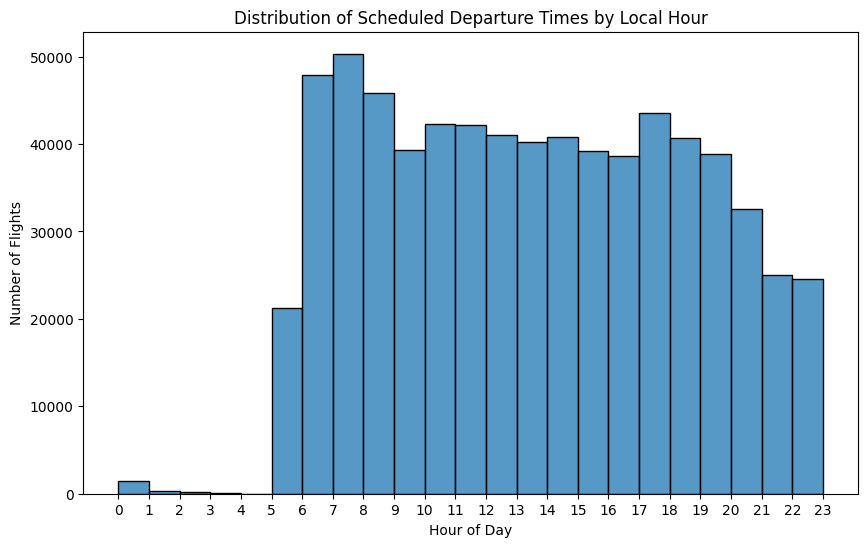

In [19]:
# plot distribution of departure times by the hour
plt.figure(figsize=(10,6))
sns.histplot(delay_df['CRS_DEP_LT'].dt.hour, bins=23, kde=False)
plt.title('Distribution of Scheduled Departure Times by Local Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Flights')
plt.xticks(range(0,24))
plt.show()
plt.close()

/var/folders/vp/t7yn0dxs05gfvmb483vp47980000gn/T/ipykernel_99662/1829382238.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  off_hour_flights['minutes_of_day'] = (off_hour_flights['CRS_DEP_LT'].dt.hour * 60 + off_hour_flights['CRS_DEP_LT'].dt.minute)


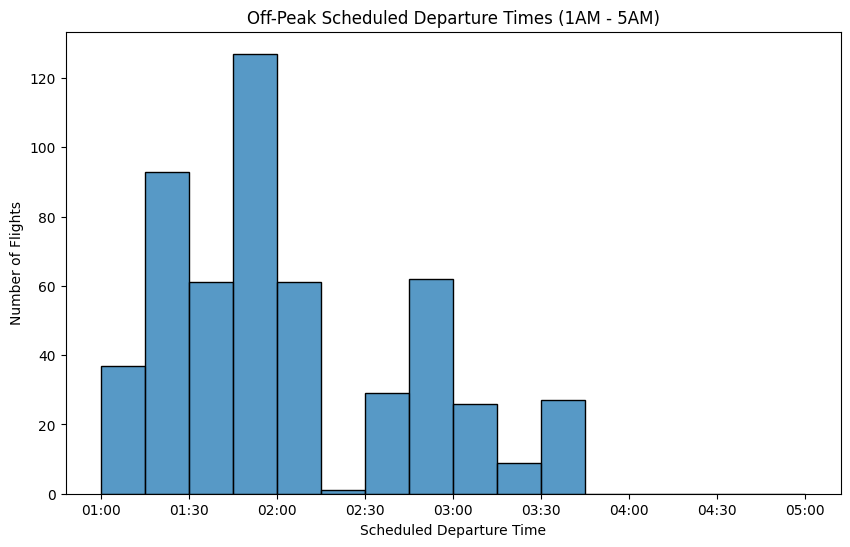

In [42]:
# plot off-peak departure in 15 minute intervals (1am-4am)
off_hour_flights = delay_df[ (delay_df['CRS_DEP_LT'].dt.hour < 5) & (delay_df['CRS_DEP_LT'].dt.hour >= 1) ]

off_hour_flights['minutes_of_day'] = (off_hour_flights['CRS_DEP_LT'].dt.hour * 60 + off_hour_flights['CRS_DEP_LT'].dt.minute)

plt.figure(figsize=(10,6))
sns.histplot(
    data=off_hour_flights, 
    x='minutes_of_day', 
    bins=range(60, 315, 15),
    kde=False
)

ticks = range(60, 315, 30)
labels = [f"{m//60:02d}:{m%60:02d}" for m in ticks]
plt.xticks(ticks, labels)

plt.title('Off-Peak Scheduled Departure Times (1AM - 5AM)')
plt.xlabel('Scheduled Departure Time')
plt.ylabel('Number of Flights')
plt.show()
plt.close()

#cleanup
del off_hour_flights

From these plots we can observe that a vast majority of flights are scheduled to depart between 5 AM and 12 AM. Scheduled departures fall off significantly after midnight and no flights were scheduled between 3:45 AM and 5 AM. With this information we can classify an aircraft's daily schedule to be between 5 AM and 3:45 the following day.

In [43]:
# Calculate universal departure time
airports = airportsdata.load('IATA')
delay_df['CRS_DEP_UTC'] = pd.NaT

def get_tz(iata_code):
    return airports[iata_code]['tz']

delay_df['DEP_TZ'] = delay_df['ORIGIN'].apply(get_tz)

#process timezones in groups
for tz, group in delay_df.groupby('DEP_TZ'):
    utc = (group['CRS_DEP_LT'].dt.tz_localize(tz, ambiguous='NaT', nonexistent='NaT').dt.tz_convert('UTC').dt.tz_localize(None))

    delay_df.loc[group.index, 'CRS_DEP_UTC'] = utc

delay_df.loc[group.index, 'CRS_DEP_UTC'] = utc

delay_df.head()

,DAY_OF_WEEK,FL_DATE,OP_CARRIER_AIRLINE_ID,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN,ORIGIN_CITY_NAME,DEST,DEST_CITY_NAME,CRS_DEP_TIME,...,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,DUP,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,CRS_DEP_LT,CRS_DEP_UTC,DEP_TZ
0,1,2025-07-07,20363,N131EV,5189,BUF,"Buffalo, NY",DTW,"Detroit, MI",1552,...,1702,1703.0,1.0,0.0,N,70.0,68.0,2025-07-07 15:52:00,2025-07-07 19:52:00,America/New_York
1,1,2025-07-07,20363,N131EV,5296,JFK,"New York, NY",BUF,"Buffalo, NY",1329,...,1512,1512.0,0.0,0.0,N,103.0,111.0,2025-07-07 13:29:00,2025-07-07 17:29:00,America/New_York
2,1,2025-07-07,20363,N131EV,5329,DTW,"Detroit, MI",CVG,"Cincinnati, OH",1820,...,1933,1914.0,-19.0,0.0,N,73.0,60.0,2025-07-07 18:20:00,2025-07-07 22:20:00,America/New_York
3,1,2025-07-07,20363,N131EV,5330,JFK,"New York, NY",ROC,"Rochester, NY",900,...,1035,1047.0,12.0,0.0,N,95.0,82.0,2025-07-07 09:00:00,2025-07-07 13:00:00,America/New_York
4,1,2025-07-07,20363,N131EV,5330,ROC,"Rochester, NY",JFK,"New York, NY",1115,...,1239,1242.0,3.0,0.0,N,84.0,72.0,2025-07-07 11:15:00,2025-07-07 15:15:00,America/New_York


In [48]:
# Create actual depature time in UTC
delay_df['DEP_TIME_LT'] = delay_df['CRS_DEP_LT'] + pd.to_timedelta(delay_df['DEP_DELAY'], unit='m')
delay_df.head()

,DAY_OF_WEEK,FL_DATE,OP_CARRIER_AIRLINE_ID,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN,ORIGIN_CITY_NAME,DEST,DEST_CITY_NAME,CRS_DEP_TIME,...,ARR_DELAY,CANCELLED,DUP,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,CRS_DEP_LT,CRS_DEP_UTC,DEP_TZ,DEP_TIME_UTC,DEP_TIME_LT
0,1,2025-07-07,20363,N131EV,5189,BUF,"Buffalo, NY",DTW,"Detroit, MI",1552,...,1.0,0.0,N,70.0,68.0,2025-07-07 15:52:00,2025-07-07 19:52:00,America/New_York,2025-07-07 19:55:00,2025-07-07 15:55:00
1,1,2025-07-07,20363,N131EV,5296,JFK,"New York, NY",BUF,"Buffalo, NY",1329,...,0.0,0.0,N,103.0,111.0,2025-07-07 13:29:00,2025-07-07 17:29:00,America/New_York,2025-07-07 17:21:00,2025-07-07 13:21:00
2,1,2025-07-07,20363,N131EV,5329,DTW,"Detroit, MI",CVG,"Cincinnati, OH",1820,...,-19.0,0.0,N,73.0,60.0,2025-07-07 18:20:00,2025-07-07 22:20:00,America/New_York,2025-07-07 22:14:00,2025-07-07 18:14:00
3,1,2025-07-07,20363,N131EV,5330,JFK,"New York, NY",ROC,"Rochester, NY",900,...,12.0,0.0,N,95.0,82.0,2025-07-07 09:00:00,2025-07-07 13:00:00,America/New_York,2025-07-07 13:25:00,2025-07-07 09:25:00
4,1,2025-07-07,20363,N131EV,5330,ROC,"Rochester, NY",JFK,"New York, NY",1115,...,3.0,0.0,N,84.0,72.0,2025-07-07 11:15:00,2025-07-07 15:15:00,America/New_York,2025-07-07 15:30:00,2025-07-07 11:30:00


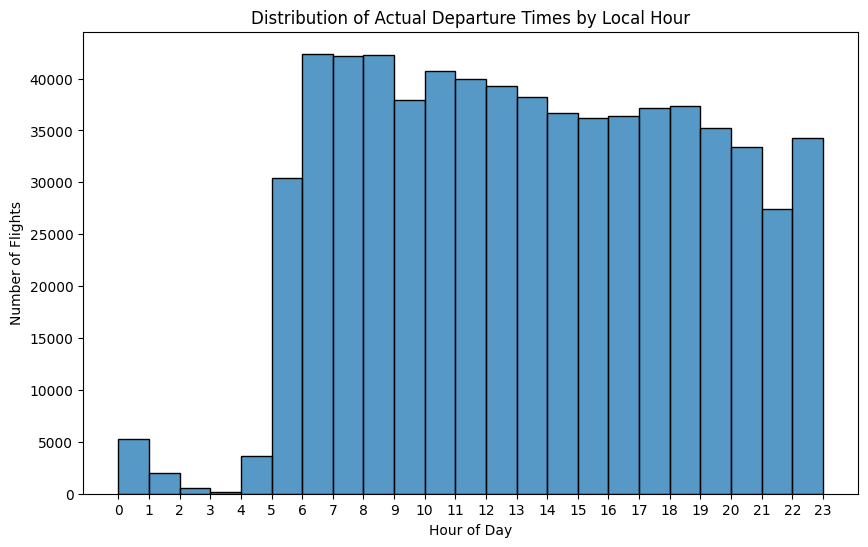

In [47]:
# plot distribution of actual departure times by the hour
plt.figure(figsize=(10,6))
sns.histplot((delay_df['CRS_DEP_LT'] + pd.to_timedelta(delay_df['DEP_DELAY'], unit='m')).dt.hour, bins=23, kde=False)
plt.title('Distribution of Actual Departure Times by Local Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Flights')
plt.xticks(range(0,24))
plt.show()
plt.close()

### Assign each flight to a chain. 

Here each chain are all flights a tail number takes from 5 AM to 3:45 AM.

### Calculate states

For this project we separate each flight into 3 states:
* On-Time: Arrives less than 15 minutes late
* Delayed: Arrives late by 15 minutes or more
* Cancelled

This results in 9 possible transitions on our markov chain.